In [31]:
# ---------------------------------------------------
# Configure project root path for module imports
# ---------------------------------------------------
# Jupyter runs from the notebooks/ directory.
# Our source code lives one level above (../src).
# We manually add the project root to sys.path
# so Python can locate the "src" package.

import sys
import os

# Add project root directory to Python path
sys.path.append(os.path.abspath(".."))

In [32]:
import pandas as pd

df = pd.read_csv("../data/raw/credit_data.csv")
df.head()

,age,employment_years,employment_type,region,annual_income,current_debt,debt_to_income_ratio,credit_utilization,number_of_credit_lines,loan_amount,loan_purpose,loan_term_months,interest_rate,late_payments_last_12m,recent_credit_inquiries,account_tenure_months,default
0,59,30.0,salaried,suburban,NaN,3604.884151,0.216077,0.772267,1,25080.235297,business,48,0.156790,1,1,176,0
1,49,30.0,self_employed,suburban,25144.300597,3879.438529,0.154287,0.723939,4,2132.467562,education,48,0.115568,1,0,142,0
2,35,7.0,salaried,urban,26125.659341,2785.891817,0.106634,0.260368,9,7646.994500,personal,48,0.151527,0,2,216,0
3,63,41.0,contractor,urban,18753.084321,14797.202548,0.789054,0.572247,4,27863.983959,business,60,0.142953,1,3,95,0
4,28,NaN,salaried,urban,NaN,18921.288887,0.660381,0.695306,7,24816.366274,mortgage,12,0.058214,2,3,107,0


In [33]:
import sys
print(sys.executable)

c:\Users\Renzo\miniforge3\envs\credit-risk\python.exe


In [34]:
# Quick diagnostics
# Data types, missing values count, column structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   employment_years         48500 non-null  float64
 2   employment_type          50000 non-null  str    
 3   region                   50000 non-null  str    
 4   annual_income            47500 non-null  float64
 5   current_debt             50000 non-null  float64
 6   debt_to_income_ratio     50000 non-null  float64
 7   credit_utilization       48000 non-null  float64
 8   number_of_credit_lines   50000 non-null  int64  
 9   loan_amount              50000 non-null  float64
 10  loan_purpose             50000 non-null  str    
 11  loan_term_months         50000 non-null  int64  
 12  interest_rate            50000 non-null  float64
 13  late_payments_last_12m   50000 non-null  int64  
 14  recent_credit_inquiries  50000 no

In [35]:
# ---------------------------
# Missing value percentage
# ---------------------------
missing_percentage = df.isnull().mean().sort_values(ascending=False)
missing_percentage

annual_income              0.05
credit_utilization         0.04
employment_years           0.03
age                        0.00
employment_type            0.00
region                     0.00
current_debt               0.00
debt_to_income_ratio       0.00
number_of_credit_lines     0.00
loan_amount                0.00
loan_purpose               0.00
loan_term_months           0.00
interest_rate              0.00
late_payments_last_12m     0.00
recent_credit_inquiries    0.00
account_tenure_months      0.00
default                    0.00
dtype: float64

In [36]:
df.dtypes

age                          int64
employment_years           float64
employment_type                str
region                         str
annual_income              float64
current_debt               float64
debt_to_income_ratio       float64
credit_utilization         float64
number_of_credit_lines       int64
loan_amount                float64
loan_purpose                   str
loan_term_months             int64
interest_rate              float64
late_payments_last_12m       int64
recent_credit_inquiries      int64
account_tenure_months        int64
default                      int64
dtype: object

In [37]:
# Count
# Mean
# Quartiles
# Standard deviation

df.describe()

,age,employment_years,annual_income,current_debt,debt_to_income_ratio,credit_utilization,number_of_credit_lines,loan_amount,loan_term_months,interest_rate,late_payments_last_12m,recent_credit_inquiries,account_tenure_months,default
count,50000.000000,48500.000000,47500.000000,50000.000000,50000.000000,48000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,44.991820,21.698268,25942.851177,11700.270163,0.458215,0.548615,4.998660,20527.739299,36.022800,0.199860,1.502020,2.000520,120.599380,0.129340
std,14.110139,14.286531,18040.069613,10434.127348,0.286942,0.259473,2.587391,11209.679225,16.958918,0.086815,1.224184,1.418591,68.349724,0.335579
min,21.000000,0.000000,-95716.076415,382.915045,0.100006,0.100010,1.000000,1001.214734,12.000000,0.050002,0.000000,0.000000,3.000000,0.000000
25%,33.000000,9.000000,15783.946089,5382.042107,0.272269,0.324636,3.000000,10829.957363,24.000000,0.124712,1.000000,1.000000,62.000000,0.000000
50%,45.000000,21.000000,22187.764377,9241.991791,0.449555,0.548974,5.000000,20586.368683,36.000000,0.199769,1.000000,2.000000,120.000000,0.000000
75%,57.000000,34.000000,31365.798019,14917.271473,0.625764,0.772456,7.000000,30156.103787,48.000000,0.274750,2.000000,3.000000,180.000000,0.000000
max,69.000000,105.000000,491942.498108,262086.726260,5.000000,0.999949,9.000000,39999.490644,60.000000,0.349998,8.000000,10.000000,239.000000,1.000000


In [38]:
from src.feature_engineering import load_raw_data, engineer_features

df = load_raw_data("../data/raw/credit_data.csv")
df = engineer_features(df)

df.describe()

,age,employment_years,annual_income,current_debt,debt_to_income_ratio,credit_utilization,number_of_credit_lines,loan_amount,loan_term_months,interest_rate,late_payments_last_12m,recent_credit_inquiries,account_tenure_months,default,income_per_credit_line
count,50000.000000,48406.000000,47407.000000,50000.000000,50000.000000,48000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47407.000000
mean,44.991820,21.578647,26042.261427,11700.270163,0.454215,0.548615,4.998660,20527.739299,36.022800,0.199860,1.502020,2.000520,120.599380,0.129340,8204.595907
std,14.110139,14.025765,17908.591252,10434.127348,0.232347,0.259473,2.587391,11209.679225,16.958918,0.086815,1.224184,1.418591,68.349724,0.335579,10343.721787
min,21.000000,0.000000,2862.880269,382.915045,0.100006,0.100010,1.000000,1001.214734,12.000000,0.050002,0.000000,0.000000,3.000000,0.000000,351.862671
25%,33.000000,9.000000,15810.909531,5382.042107,0.272269,0.324636,3.000000,10829.957363,24.000000,0.124712,1.000000,1.000000,62.000000,0.000000,2913.614959
50%,45.000000,21.000000,22214.808119,9241.991791,0.449555,0.548974,5.000000,20586.368683,36.000000,0.199769,1.000000,2.000000,120.000000,0.000000,4872.008688
75%,57.000000,34.000000,31383.072499,14917.271473,0.625764,0.772456,7.000000,30156.103787,48.000000,0.274750,2.000000,3.000000,180.000000,0.000000,9325.561254
max,69.000000,45.000000,491942.498108,262086.726260,3.000000,0.999949,9.000000,39999.490644,60.000000,0.349998,8.000000,10.000000,239.000000,1.000000,491942.498108


In [39]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['age', 'employment_years', 'annual_income', 'current_debt', 'debt_to_income_ratio', 'credit_utilization', 'number_of_credit_lines', 'loan_amount', 'loan_term_months', 'interest_rate', 'late_payments_last_12m', 'recent_credit_inquiries', 'account_tenure_months', 'default', 'income_per_credit_line']

Categorical columns: ['employment_type', 'region', 'loan_purpose']


C:\Users\Renzo\AppData\Local\Temp\ipykernel_10616\668040174.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [40]:
# Check class imbalance
df["default"].value_counts(normalize=True)

default
0    0.87066
1    0.12934
Name: proportion, dtype: float64

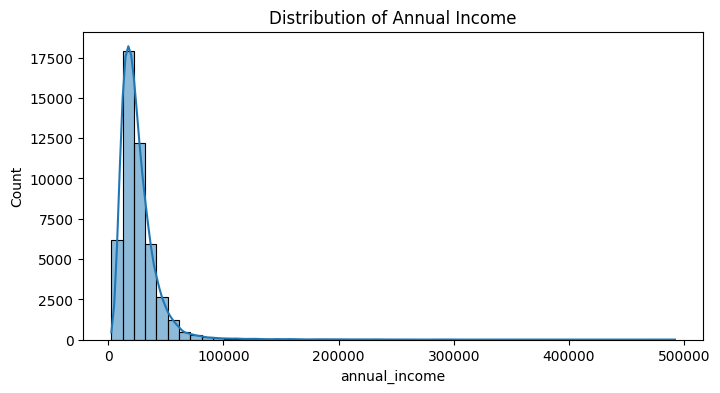

In [42]:
# Income distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df["annual_income"], bins=50, kde=True)
plt.title("Distribution of Annual Income")
plt.show()

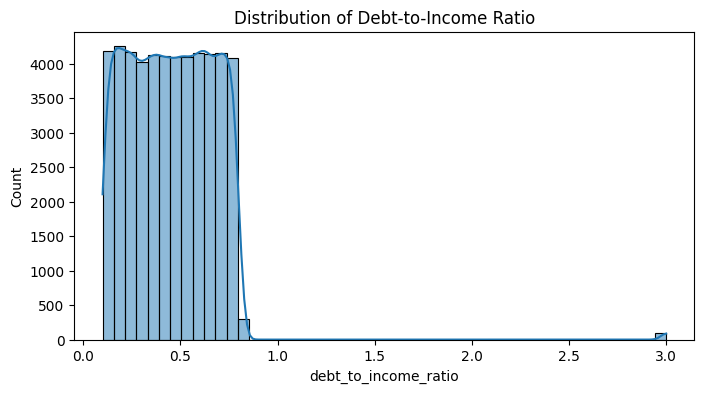

In [44]:
# Debt-to-Income Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["debt_to_income_ratio"], bins=50, kde=True)
plt.title("Distribution of Debt-to-Income Ratio")
plt.show()

In [45]:
# Default Rate by Employment Type

df.groupby("employment_type")["default"].mean().sort_values()

employment_type
salaried         0.113102
contractor       0.120631
self_employed    0.144545
unemployed       0.298150
Name: default, dtype: float64

In [46]:
# ============================================================
# EDA CONCLUSIONS
# ============================================================

# 1) Dataset Structure
# ------------------------------------------------------------
# The dataset contains a mix of numerical and categorical features.
# Numerical features include financial ratios, income variables,
# behavioral counts, and engineered metrics.
# Categorical features include employment_type, region, and loan_purpose.

# 2) Class Imbalance
# ------------------------------------------------------------
# The default rate is approximately 13%, which reflects a realistic
# credit risk portfolio scenario.
# The dataset is imbalanced but not excessively so.
# Accuracy is not an appropriate metric; ROC-AUC will be preferred.
# Class weighting may be considered during model training.

# 3) Income Distribution
# ------------------------------------------------------------
# Annual income follows a strong right-skewed (log-normal) distribution.
# There is a long upper tail with high-income outliers.
# Scaling is necessary for linear models.
# Log transformation could be explored but is not mandatory.

# 4) Debt-to-Income Ratio
# ------------------------------------------------------------
# The debt-to-income ratio is concentrated between 0 and 1,
# with extreme values capped at 3 during rule-based cleaning.
# The capping strategy successfully removed artificial extreme values.
# No further transformation appears necessary at this stage.

# 5) Categorical Risk Signal
# ------------------------------------------------------------
# Default rates vary significantly by employment_type.
# Unemployed clients exhibit substantially higher default probability (~29%),
# confirming that categorical variables contain predictive signal.
# Encoding is required for model compatibility.

# 6) Missing Values
# ------------------------------------------------------------
# Missing values are present in both numerical and categorical features.
# These were intentionally preserved after rule-based cleaning.
# Imputation will be handled within a structured preprocessing pipeline.

# 7) Data Realism & Business Coherence
# ------------------------------------------------------------
# The synthetic dataset demonstrates financially coherent relationships:
# - Higher debt ratios increase default probability
# - Higher income and employment stability reduce risk
# - Behavioral variables contribute to risk modeling
# The dataset is suitable for building and comparing predictive models.

# ============================================================
# Next Step: Structured preprocessing pipeline (imputation,
# encoding, scaling, and model integration).
# ============================================================